## 1. Network Structure Comparison

- Graph metrics: Degree distribution, clustering coefficient, diameter, betweenness centrality, modularity, etc.

- Community structure: How tightly knit are the communities (e.g., Hogwarts Houses vs. the Fellowship)?

- Central characters: Compare who acts as social hubs or bridges (e.g., Dumbledore vs. Gandalf).

- Resilience: What happens to the network if you remove key characters (simulate “killing off” Dumbledore or Frodo)?


### Question:
- *Which universe has a more centralized social structure?*
- *Is one universe more hierarchical or egalitarian in terms of interactions?*

## 2. Role and Archetype Similarity

- Use the graph structure to explore role equivalence:

- Identify structural equivalents across universes: e.g., Frodo ↔ Harry (protagonists), Gandalf ↔ Dumbledore (mentor), Sauron ↔ Voldemort (villain).

- Use graph embedding or role similarity algorithms (like node2vec) to find characters that occupy similar positions in their networks.

### Questions:

- *Can we identify parallel roles purely from network structure, without narrative context?*

## 3. Sentiment & Relationship Types

- Label edges as positive (friendship) or negative (conflict).

- Compare the balance of positive vs. negative relationships.

- See how negativity propagates (e.g., Voldemort and Sauron as sources of “negative influence”).

### Question:

- *Which universe is “happier” in its social graph?*
- *Is the Lord of the Rings network more polarized than the Harry Potter one?*

Spiseseddel/To-do list:
Harrypotter side:       https://harrypotter.fandom.com/wiki/Main_Page
Lord of the Rings side: https://lotr.fandom.com/wiki/Main_Page

1. Identificer karakter sider:
    - HP: https://harrypotter.fandom.com/wiki/Category:Individuals
    - LOTR: https://lotr.fandom.com/wiki/Category:Characters

2. Find ud af hvordan fandom.com api fungere (https://chatgpt.com/s/t_690b2537f16481919516ba98b1162d55)
3. Lav function som henter alt text fra en fandom.com side.
    1. Gå igennem alle links på category siden.
    2. Hvis link er kategori så åbn den nye kategori side og gå tilbage til 1, 
    hvis ikke så kig om den side er blevet downloadet, hvis ikke så download, ellers fortsæt.
    3. Gem både karakter og side tekst
4. Start analyse. Lav video på 1:30 min til projA 

In [1]:
import networkx as nx 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import re, pickle, powerlaw, urllib.request, json, time
from collections import Counter

/Users/frejatusindfryd/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Part 0: Download the data

In [4]:
download = False # Set true if you wish to re-download

In [2]:
def get_category_members(url, page_name):
    base_url = f'https://{url}/api.php?'
    query = (
        f"{base_url}"
        f"action=query&list=categorymembers&cmtitle={urllib.parse.quote(page_name)}"
        f"&cmlimit=max&format=json"
    )
    request = urllib.request.Request(query)
    request.add_header('User-Agent', 'YourAppName/1.0 (s204229@student.dtu.dk)')
    with urllib.request.urlopen(request) as response:
        wikidata = json.loads(response.read())
        return [member['title'] for member in wikidata['query']['categorymembers']]


def extract_characters_and_categories(response, downloaded_categories):
    # Words that indicate non-character categories
    blacklist = ['places', 'creatures', 'locations', 'objects', 'languages',
                 'rivers', 'mountains', 'events', 'battles', 'wars', 'books',
                 'families', 'songs', 'terms', 'legends', 'real-world', 'media', 
                 'non-canonical', 'images', 'ranks', 'titles']
    
    characters = []
    categories = []

    for title in response:
        if title.startswith('Category:'):
            # Normalize for comparison
            lower = title.lower()
            if any(bad in lower for bad in blacklist):
                continue  # skip non-character categories
            if title not in downloaded_categories:
                categories.append(title)
        else:
            # Keep only likely character pages (heuristic: no colon, not "Category:", not image)
            if ':' not in title and not title.lower().startswith('list of'):
                characters.append(title)
    return list(set(characters)), list(set(categories))


def get_all_characters(url, root_category='Category:Characters'):
    downloaded_categories = [root_category]
    response = get_category_members(url, root_category)
    characters, categories = extract_characters_and_categories(response, downloaded_categories)

    while categories:
        current = categories.pop(0)
        downloaded_categories.append(current)
        #print(f"{len(categories)} remaining. Fetching: {current}")
        response = get_category_members(url, current)
        char, cat = extract_characters_and_categories(response, downloaded_categories)
        characters = list(set(characters + char))
        categories = list(set(categories))# + cat))
        time.sleep(0.5)

    return sorted(set(characters))

def download_pages(url, page_names, batch_size=25):
    api_url = f'https://{url}/api.php'
    results = []

    for i in range(0, len(page_names), batch_size):
        batch = page_names[i:i+batch_size]
        clean_batch = [t for t in batch if t and not any(c in t for c in '\n\r{}')]
        if not clean_batch:
            continue

        data = {
            'action': 'query',
            'prop': 'revisions',
            'rvprop': 'content',
            'titles': '|'.join(clean_batch),
            'format': 'json'
        }

        encoded = urllib.parse.urlencode(data).encode('utf-8')
        request = urllib.request.Request(api_url, data=encoded)
        request.add_header('User-Agent', 'YourAppName/1.0 (s204229@student.dtu.dk)')

        try:
            with urllib.request.urlopen(request) as response:
                wikidata = json.loads(response.read())
                for key, page in wikidata['query']['pages'].items():
                    revisions = page.get('revisions', [{}])
                    content = revisions[0].get('*', '') if revisions else ''
                    results.append({
                        'page_name': page.get('title', ''),
                        'content': content
                    })
        except urllib.error.HTTPError as e:
            print(f"HTTP Error {e.code} on batch {i//batch_size + 1}: {e.reason}")
        time.sleep(0.3)
    return results


In [5]:
if download:
    url             = 'lotr.fandom.com'
    category_name   = 'Category:Characters'
    page_names      = get_all_characters(url, category_name)
    print(f'There are {len(page_names)} characters in Lord of the Rings')
    print(f'First 10 pages:\n {page_names[10:]}')

    lotr_pages = download_pages(url, page_names)
    with open("lotr_characters.pkl", "wb") as f:   # 'wb' = write binary
        pickle.dump(lotr_pages, f)

In [6]:
if download:
    url             = 'harrypotter.fandom.com'
    category_name   = 'Category:Individuals'
    page_names      = get_all_characters(url, category_name)
    print(f'There are {len(page_names)} characters in Harry Potter')
    print(f'First 10 pages:\n {page_names[10:]}')

    hp_pages = download_pages(url, page_names)
    with open("hp_characters.pkl", "wb") as f:   # 'wb' = write binary
        pickle.dump(hp_pages, f)

### Part 1: Create the networks

In [7]:
def extract_infobox(content):
    # Step 1: find the starting point of the infobox
    start_match = re.search(r"\{\{[^{}]{0,50}?[Ii]nfobox", content, flags=re.IGNORECASE)
    if not start_match:
        return None

    start_index = start_match.start()

    # Step 2: walk forward and find the matching braces
    brace_count = 0
    i = start_index
    while i < len(content):
        if content[i:i+2] == "{{":
            brace_count += 1
            i += 2
            continue
        elif content[i:i+2] == "}}":
            brace_count -= 1
            i += 2
            if brace_count == 0:
                return content[start_index:i]  # extract full infobox
            continue
        else:
            i += 1

    return None  # fallback if somehow unbalanced

def extract_field(text, field):
    lines = text.splitlines()
    capture = False
    genre_lines = []
    for line in lines:
        if not capture:
            if re.match(rf'\|\s*{field}\s*=', line, flags=re.I):
                line = re.sub(rf'\|\s*{field}\s*=\s*', '', line, flags=re.I)
                genre_lines.append(line)
                capture = True
        else:
            if re.match(r'\|\s*\w+\s*=', line):
                break
            genre_lines.append(line)
    return '\n'.join(genre_lines).strip()

def extract_name(text):
    pattern = r"\[\[(.*?)\]\]"
    matches = re.findall(pattern, text)
    return matches

def extract_origin(text, field):
    return extract_name(extract_field(extract_infobox(text), field))

# Declare helper functions
def clean_links(links):
    arr = []
    for l in links:
        match = re.search(r'|', l)
        if match:
            splits = l.split(r'|')
            arr.append(splits[0].replace(' ', '_'))
        else:
            arr.append(l.replace(' ', '_'))
    return arr

def analyze_node(data_point, field_origin, field_species):
    Node = data_point['page_name']
    text = data_point['content']
    words = len(text.split())
    try:
        origin = extract_origin(text, field_origin)
    except:
        origin = None

    try:
        species = extract_origin(text, field_species)
    except:
        species = None
    links_to = re.findall(r'\[\[([^\]]+)\]\]', text)
    links_to = clean_links(links_to)
    return Node, links_to, words, origin, species

def create_network(data, field_origin, field_species, use_only_largest_component = True):
    for entry in data:
        entry['page_name'] = entry['page_name'].replace(' ','_')
    G = nx.DiGraph()
    non_links = []
    Nodes = list(set([data_point['page_name'] for data_point in data]))
    for data_point in data:
        Node, links_to, words, origin, species = analyze_node(data_point, field_origin, field_species)
        G.add_node(Node, words=words, origin = origin, species = species)
        for links_to_node in links_to:
            if links_to_node in Nodes:
                G.add_edge(Node, links_to_node)
            else:
                non_links.append(links_to_node)

    G = G.subgraph([node for node, deg in G.degree() if deg > 0])
    if use_only_largest_component:
        # Extract the largest component
        components = nx.weakly_connected_components(G)
        largest = max(components, key=len)
        G = G.subgraph(largest).copy()
    
    return G

In [10]:
def print_data(data):
    N = len(data)
    total_n_words = 0
    for entry in data:
        total_n_words += len(entry['content'].split())
    print(f'There are {N:,} pages in the wiki-data source and a total of {total_n_words:,} words on all of the pages combined. Words/Pages: {total_n_words/N:.0f}\n')

def printy(G):
    print(f"Number of nodes: {len(G.nodes())}.\n"
      f"Number of Edges: {len(G.edges())}.\n"
      f"Average degree: {np.average([deg for _, deg in G.degree()]):.2f}.\n"
      f"Average clustering: {nx.average_clustering(G):.2f}.\n"
      f"Average number of words: {np.mean([data['words'] for _, data in G.nodes(data=True)]):.2f}")

def create_centrality_table(G, top = 10):
    in_degree               = [node for node, _ in sorted([(node, degree) for node, degree in G.in_degree()], key = lambda x: x[1], reverse = True)[:top]]
    out_degree              = [node for node, _ in sorted([(node, degree) for node, degree in G.out_degree()], key = lambda x: x[1], reverse = True)[:top]]
    degree_centrality       = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.degree_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    betweenness_centrality  = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.betweenness_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    eigenvector_centrality  = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.eigenvector_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    words                   = [node for node, _ in sorted([(node, data['words']) for node, data in G.nodes(data=True)], key = lambda x: x[1], reverse = True)[:top]]

    print(f"{'Rank':<5} {'In-degree':>30} {'Out-degree':>30} {'Degree centrality':>30} "
      f"{'Betweenness centrality':>30} {'Eigenvector centrality':>30} {'Length of content':>30}")
    print('-' * 200)
    for i in range(len(degree_centrality)):
        print(f'{i+1:<5} {in_degree[i]:>30} {out_degree[i]:>30} {degree_centrality[i]:>30} {betweenness_centrality[i]:>30} {eigenvector_centrality[i]:>30} {words[i]:>30}')

def plot_degree_distributions(G, bins=30):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.titlesize": 16
    })
    

    in_deg = [deg for _, deg in G.in_degree() if deg > 0]
    alpha_in = powerlaw.Fit(in_deg).alpha
    out_deg = [deg for _, deg in G.out_degree() if deg > 0]
    alpha_out = powerlaw.Fit(out_deg).alpha
    deg = [deg for _, deg in G.degree() if deg > 0]
    alpha = powerlaw.Fit(deg).alpha

    # Define shared bin edges
    in_max = max(in_deg)
    out_max = max(out_deg)

    in_bins = np.linspace(0, in_max, bins+1)
    out_bins = np.linspace(0, out_max, bins+1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))

    # In-degree plots (shared bins)
    axes[0].hist(in_deg, bins=in_bins, color="#1f77b4", alpha=0.8, edgecolor="black")
    axes[0].set_title(f"In-degree distribution \nDegree exponent (alpha): {alpha_in:.2f}")

    axes[1].hist(out_deg, bins=out_bins, color="#ff7f0e", alpha=0.8, edgecolor="black")
    axes[1].set_title(f"Out-degree distribution \nDegree exponent (alpha): {alpha_out:.2f}")

    axes[2].hist(deg, bins=out_bins, color="#00c22a", alpha=0.8, edgecolor="black")
    axes[2].set_title(f"Total degree distribution \nDegree exponent (alpha): {alpha:.2f}")

    fig.suptitle("Degree Distributions", fontsize=18, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def disparity_filter(G, alpha_threshold):
    # Create an empty graph of the same type
    backbone = G.__class__()
    backbone.add_nodes_from(G.nodes(data=True))

    # Compute normalized weights and significance for each node
    for i in G.nodes():
        k_i = len(G[i])
        if k_i <= 1:
            continue

        s_i = sum(G[i][j].get('viz_weight', 1.0) for j in G[i])
        for j in G[i]:
            w_ij = G[i][j].get('viz_weight', 1.0)
            p_ij = w_ij / s_i
            alpha_ij = 1 - (1 - p_ij) ** (k_i - 1)
            G[i][j]['alpha_' + str(i)] = alpha_ij

    # For undirected graphs, use the maximum significance (conservative choice)
    if not G.is_directed():
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            alpha_j = data.get('alpha_' + str(j), 1)
            alpha = min(alpha_i, alpha_j)
            if alpha < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha})
    else:
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            if alpha_i < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha_i})

    return backbone


def normalize(x, min_, max_):
    return (x - min_) / (max_ - min_) * 100

def plot_backbone(G, alpha_threshold=0.5, node_size=50, edge_width=1,
                  nodes_cmap=plt.cm.viridis, edge_cmap=plt.cm.Blues):
    G = G.copy()

    plt.figure(figsize=(10,10))

    # Compute betweenness-based visualization weights
    betweenness = nx.edge_betweenness_centrality(G)
    min_bw, max_bw = min(betweenness.values()), max(betweenness.values())
    for (u, v), w in betweenness.items():
        G[u][v]['viz_weight'] = normalize(w, min_bw, max_bw)

    # Extract backbone
    backbone = disparity_filter(G, alpha_threshold)
    
    # Remove nodes with degree less than 5
    to_remove = [n for n, d in backbone.degree() if d < 5]
    backbone.remove_nodes_from(to_remove)

    # Compute node centrality
    centrality = nx.betweenness_centrality(backbone)
    min_c, max_c = min(centrality.values()), max(centrality.values())
    values = [normalize(centrality[n], min_c, max_c) for n in backbone.nodes()]
    # Layout
    try:
        pos = nx.forceatlas2_layout(backbone, seed = 42)
    except:
        pos = nx.spring_layout(backbone, seed = 42)

    weights = [G[u][v].get('viz_weight', 1.0) for u, v in backbone.edges()]
    # Draw edges
    nx.draw_networkx_edges(backbone, pos, width=edge_width,
                           edge_color=weights, edge_cmap=edge_cmap, alpha=1.)

    # Draw nodes
    nx.draw_networkx_nodes(backbone, pos, node_size=[v + node_size for v in values],
                           node_color=values, cmap=nodes_cmap, alpha=1)

    plt.axis("off")
    plt.title(f"Network Backbone ({backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges)")
    plt.show()

def print_attribute(G, attribute, top_n = 5):
    arr = [ data[attribute][0] if data[attribute] else 'None' for _, data in G.nodes(data=True) ]
    distinct_attributes = set(arr)
    print(f'Distinct {attribute}s: {len(distinct_attributes)}')
    print(f'\nTop {top_n} {attribute}s')
    print('-'*80)
    print(f'{"Rank":<5} {f"{attribute}":>30} {"Count":>40}')
    print('-'*80)
    counts = Counter(arr)
    top = counts.most_common(top_n)
    for i, (att, count) in enumerate(top):
        print(f'{i+1:<5} {att:>30} {count:>40}')

#### Harry Potter initial data analysis

There are 998 pages in the wiki-data source and a total of 868,983 words on all of the pages combined. Words/Pages: 871

Number of nodes: 506.
Number of Edges: 1767.
Average degree: 6.98.
Average clustering: 0.39.
Average number of words: 1513.22

Rank                       In-degree                     Out-degree              Degree centrality         Betweenness centrality         Eigenvector centrality              Length of content
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                       Harry_Potter                   Harry_Potter                   Harry_Potter                   Harry_Potter                   Harry_Potter                   Harry_Potter
2                         Tom_Riddle               Albus_Dumbledore               Albus_Dumbledore               Albus_Dumbledore                     Tom_Riddle       

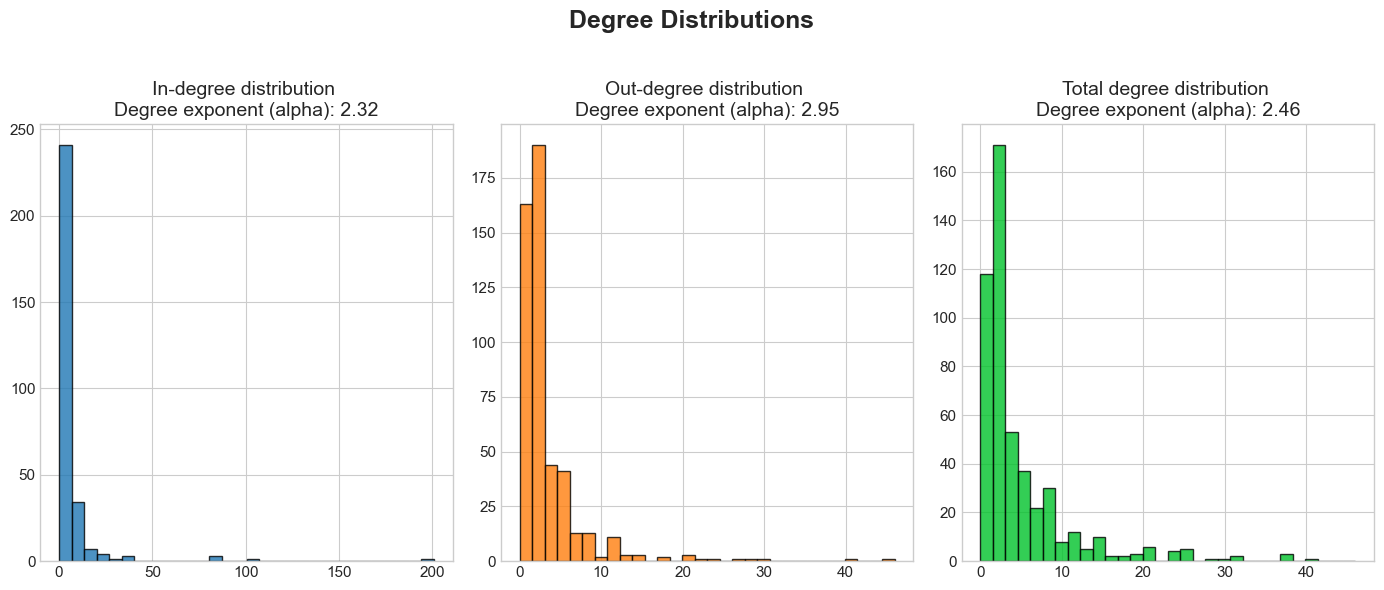

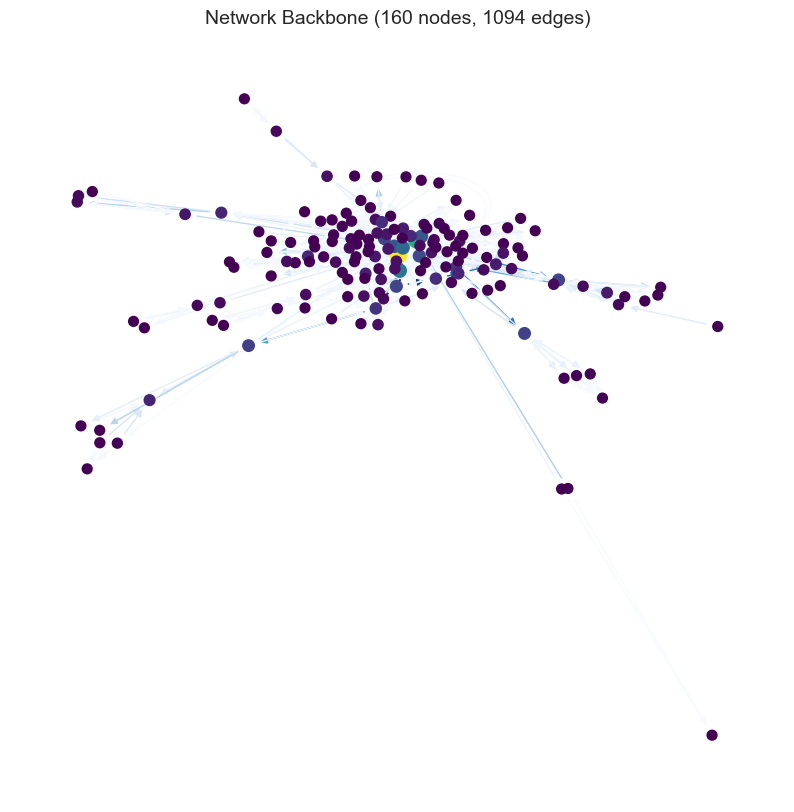

In [11]:
with open("hp_characters.pkl", "rb") as f:   # 'rb' = read binary
    HP_data = pickle.load(f)
    
HP_network = create_network(HP_data, field_origin = 'house', field_species = 'species')
print_data(HP_data)
printy(HP_network)
print()
create_centrality_table(HP_network)
print()
print_attribute(HP_network, 'species')
print()
print_attribute(HP_network, 'origin')
print()
plot_degree_distributions(HP_network)
plot_backbone(HP_network, alpha_threshold=1)

#### Lord of the Rings initial data analysis

There are 895 pages in the wiki-data source and a total of 711,845 words on all of the pages combined. Words/Pages: 795

Number of nodes: 877.
Number of Edges: 6240.
Average degree: 14.23.
Average clustering: 0.42.
Average number of words: 807.63

Rank                       In-degree                     Out-degree              Degree centrality         Betweenness centrality         Eigenvector centrality              Length of content
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                             Sauron                         Sauron                         Sauron                         Sauron                         Sauron                         Sauron
2                              Valar                        Morgoth                        Gandalf                     Aragorn_II                        Gandalf       

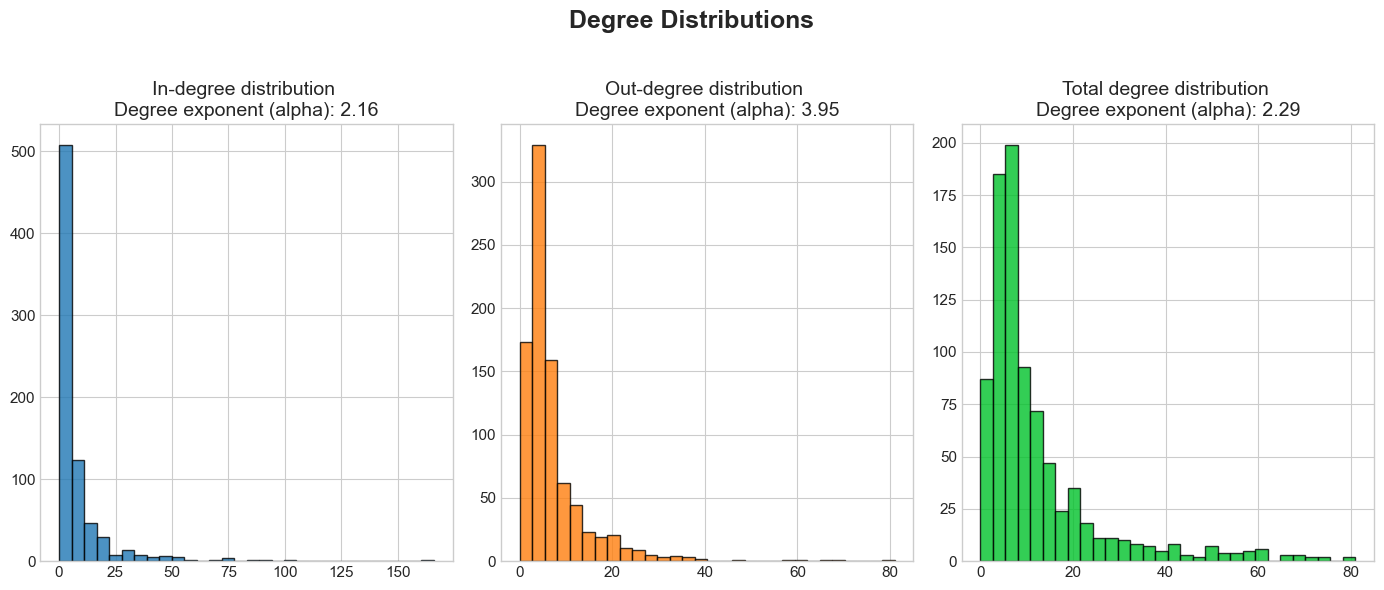

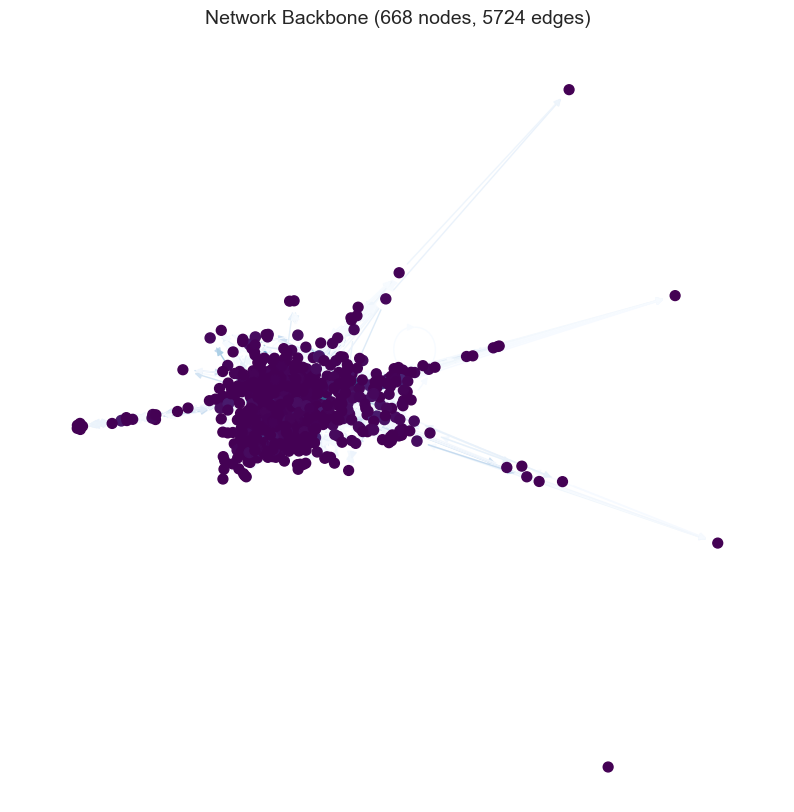

In [12]:
with open("lotr_characters.pkl", "rb") as f:   # 'rb' = read binary
    LOTR_data = pickle.load(f)

LOTR_network = create_network(LOTR_data, field_origin = 'culture', field_species = 'race')
print_data(LOTR_data)
printy(LOTR_network)
print()
create_centrality_table(LOTR_network)
print()
print_attribute(LOTR_network, 'species')
print()
print_attribute(LOTR_network, 'origin')
print()
plot_degree_distributions(LOTR_network)
plot_backbone(LOTR_network, alpha_threshold=1)

In [13]:
[node  for node, data in LOTR_network.nodes(data=True) if data['origin']]

['Galadriel',
 'Adanel',
 'Belemir',
 'Malach',
 'Bëor',
 'Emeldir',
 'Beren',
 'Andreth',
 'Baran',
 'Barahir',
 'Adar',
 'Morgoth',
 'Sauron',
 'Arondir',
 'Tar-Míriel',
 'Gil-galad',
 'Adelard_Took',
 'Bilbo_Baggins',
 'Adrahil_I',
 'Adrahil_II',
 'Imrazôr',
 'Ondoher',
 'Galador',
 'Minohtar',
 'Eärnil_II',
 'Amroth',
 'Angelimir',
 'Ivriniel',
 'Imrahil',
 'Aegnor',
 'Angrod',
 'Finarfin',
 'Fëanor',
 'Figwit',
 'Eärendil',
 'Erellont',
 'Eönwë',
 'Manwë',
 'Aerin',
 'Indor',
 'Húrin',
 'Morwen',
 'Sador',
 'Túrin',
 'Agaldor',
 'Galdor',
 'Meleth',
 'Manthor',
 'Hunthor',
 'Aglahad',
 'Ailinel',
 'Tar-Meneldur',
 'Almarian',
 'Soronto',
 'Tar-Aldarion',
 'Almiel',
 'Ulmo',
 'Aulë',
 'Oromë',
 'Tulkas',
 'Varda',
 'Yavanna',
 'Nienna',
 'Estë',
 'Vairë',
 'Vána',
 'Nessa',
 'Melian',
 'Aragorn_II',
 'Elros',
 'Alatar',
 'Pallando',
 'Saruman',
 'Gandalf',
 'Radagast',
 'Thráin_II',
 'Frodo_Baggins',
 'Samwise_Gamgee',
 'Peregrin_Took',
 'Meriadoc_Brandybuck',
 'Aldamir',
 'Castami